In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cp /content/drive/MyDrive/fer2013plus.zip /content/

In [ ]:
!mkdir fer2013plus/

In [ ]:
!unzip fer2013plus.zip -d /content/fer2013plus/

Streaming output truncated to the last 5000 lines.
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017527.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017536.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017542.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017574.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017577.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017579.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017584.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017610.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017616.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017623.png  
  inflating: /content/fer2013plus/fer2013plus/fer2013/train/sadness/fer0017633.png  
  inflating: /

## Defining architechure and train function


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.ImageFolder('/content/fer2013plus/fer2013plus/fer2013/train/', transform=transform_train)
test_dataset  = datasets.ImageFolder('/content/fer2013plus/fer2013plus/fer2013/test/', transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

class FER_DCNN(nn.Module):
    def __init__(self):
        super(FER_DCNN, self).__init__()

        # Helper to create a block with 2 convs per block
        def conv_block(in_f, out_f, dropout_rate):
            return nn.Sequential(
                nn.Conv2d(in_f, out_f, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_f),
                nn.ELU(),
                nn.Conv2d(out_f, out_f, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_f),
                nn.ELU(),
                nn.MaxPool2d(2),
                nn.Dropout(dropout_rate)
            )

        # 1. Conv block count: 3 sets
        # 2. Filter counts: 64, 128, 256
        # 3. Dropout (conv): Rate 0.3 for all blocks
        self.features = nn.Sequential(
            conv_block(1, 64, 0.3),   # Block 1
            conv_block(64, 128, 0.3),  # Block 2
            conv_block(128, 256, 0.3)  # Block 3
        )

        # 4. Dense layers: 1 dense, 128 neurons
        # Spatial size logic: 48 -> 24 -> 12 -> 6 (after 3 MaxPools)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(0.4),          # 5. Dropout (dense): Rate 0.4
            nn.Linear(128, 8)         # Keeping 8 output neurons as per your code
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FER_DCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0  # Initialize total_loss

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels) # Calculate loss
            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() # Accumulate loss
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total, total_loss / len(loader) # Return both accuracy and loss


## Training Model

In [ ]:
# Training loop
best_acc, best_val_loss = 0, float('inf')
patience, no_improve_count, epoch = 10, 0, 0

while True:
    train_loss        = train_epoch(model, train_loader)
    val_acc, val_loss = evaluate(model, test_loader)

    scheduler.step(val_loss)

    # Save best checkpoint (model + optimizer + scheduler state)
    if val_acc > best_acc + 1e-4:
        best_acc = val_acc
        no_improve_count = 0
        torch.save({
            'epoch':                epoch + 1,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc':         best_acc,
            'val_loss':             val_loss,
        }, "best_fer_model.pth")
        print(f"  ✔ Checkpoint saved  (val_acc={best_acc:.4f})")
    else:
        no_improve_count += 1

    print(f"Epoch {epoch+1}: TrainLoss={train_loss:.4f}  ValLoss={val_loss:.4f}  "
          f"ValAcc={val_acc:.4f}  NoImprove={no_improve_count}/{patience}")

    if no_improve_count >= patience:
        print(f"Converged at epoch {epoch+1}. Best Val Acc: {best_acc:.4f}")
        break

    epoch += 1


  ✔ Checkpoint saved  (val_acc=0.6530)
Epoch 1: TrainLoss=1.2268  ValLoss=0.9726  ValAcc=0.6530  NoImprove=0/10
  ✔ Checkpoint saved  (val_acc=0.6909)
Epoch 2: TrainLoss=0.9310  ValLoss=0.8839  ValAcc=0.6909  NoImprove=0/10
  ✔ Checkpoint saved  (val_acc=0.7155)
Epoch 3: TrainLoss=0.8545  ValLoss=0.7983  ValAcc=0.7155  NoImprove=0/10
  ✔ Checkpoint saved  (val_acc=0.7294)
Epoch 4: TrainLoss=0.8021  ValLoss=0.7560  ValAcc=0.7294  NoImprove=0/10
  ✔ Checkpoint saved  (val_acc=0.7445)
Epoch 5: TrainLoss=0.7564  ValLoss=0.7284  ValAcc=0.7445  NoImprove=0/10
Epoch 6: TrainLoss=0.7298  ValLoss=0.7328  ValAcc=0.7362  NoImprove=1/10
  ✔ Checkpoint saved  (val_acc=0.7642)
Epoch 7: TrainLoss=0.6930  ValLoss=0.6783  ValAcc=0.7642  NoImprove=0/10
Epoch 8: TrainLoss=0.6760  ValLoss=0.6602  ValAcc=0.7622  NoImprove=1/10
  ✔ Checkpoint saved  (val_acc=0.7683)
Epoch 9: TrainLoss=0.6517  ValLoss=0.6497  ValAcc=0.7683  NoImprove=0/10
  ✔ Checkpoint saved  (val_acc=0.7694)
Epoch 10: TrainLoss=0.6355  Val

## Evaluation Metrics

Loaded checkpoint from epoch 34  (best val_acc=0.8081)
  CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.7884    0.6941    0.7382       644
    contempt     0.8000    0.1569    0.2623        51
     disgust     0.8000    0.3509    0.4878        57
        fear     0.6602    0.4072    0.5037       167
   happiness     0.8991    0.9026    0.9008      1827
     neutral     0.7889    0.8864    0.8348      2597
     sadness     0.6835    0.5549    0.6125       856
    surprise     0.8110    0.8533    0.8316       900

    accuracy                         0.8081      7099
   macro avg     0.7789    0.6008    0.6465      7099
weighted avg     0.8044    0.8081    0.8011      7099

Top-1 Accuracy : 80.81%
Top-2 Accuracy : 93.22%
MCC            : 0.7447  (1=perfect, 0=random, -1=inverse)
Cohen's Kappa  : 0.7431  (>0.6 substantial, >0.8 almost perfect)


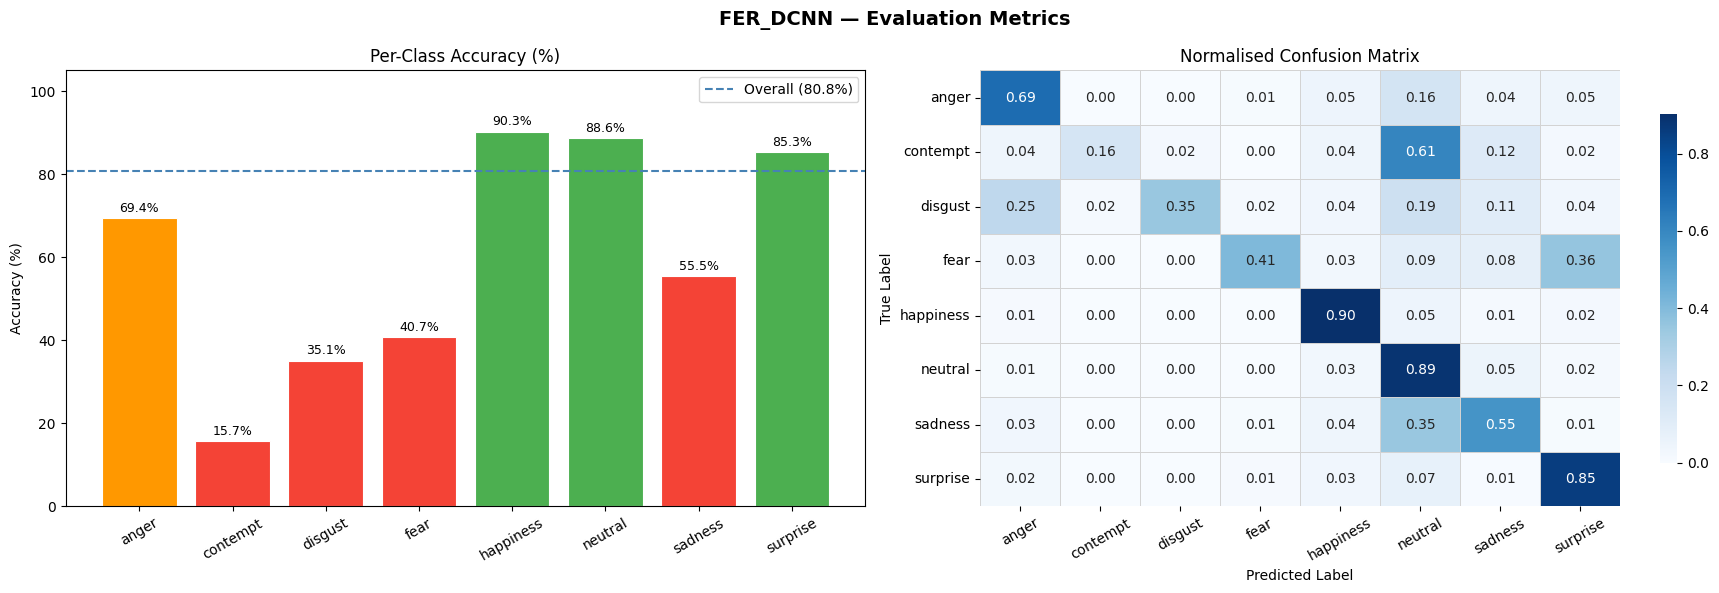


Plot saved → evaluation_metrics.png


In [ ]:
# =============================================================================
#  EVALUATION METRICS
#  Runs on the held-out test set using the best saved checkpoint.
#  Computes:
#    • Per-class Precision / Recall / F1-score  (macro + weighted averages)
#    • Confusion matrix  (raw counts + normalised)
#    • Top-1 and Top-2 accuracy
#    • Matthews Correlation Coefficient  (MCC)
#    • Cohen's Kappa
# =============================================================================
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score, top_k_accuracy_score
)

# ── 1.  Collect all predictions & probabilities ──────────────────────────────
checkpoint = torch.load("best_fer_model.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  (best val_acc={checkpoint['best_val_acc']:.4f})")
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = torch.argmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs  = np.concatenate(all_probs)

class_names = test_loader.dataset.classes   # e.g. ['angry','disgust',...]

# ── 2.  Classification report  (per-class P / R / F1) ───────────────────────
print("=" * 70)
print("  CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4))

# ── 3.  Top-1 and Top-2 accuracy ─────────────────────────────────────────────
top1 = (all_preds == all_labels).mean()
top2 = top_k_accuracy_score(all_labels, all_probs, k=2)
print(f"Top-1 Accuracy : {top1*100:.2f}%")
print(f"Top-2 Accuracy : {top2*100:.2f}%")

# ── 4.  MCC and Cohen's Kappa ────────────────────────────────────────────────
mcc   = matthews_corrcoef(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)
print(f"MCC            : {mcc:.4f}  (1=perfect, 0=random, -1=inverse)")
print(f"Cohen's Kappa  : {kappa:.4f}  (>0.6 substantial, >0.8 almost perfect)")
print("=" * 70)

# ── 5.  Per-class accuracy bar chart ─────────────────────────────────────────
cm         = confusion_matrix(all_labels, all_preds)
per_class  = cm.diagonal() / cm.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("FER_DCNN — Evaluation Metrics", fontsize=14, fontweight="bold")

# Bar chart
colors = ["#4CAF50" if v >= 0.75 else "#FF9800" if v >= 0.60 else "#F44336"
          for v in per_class]
bars = axes[0].bar(class_names, per_class * 100, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Per-Class Accuracy (%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 105)
axes[0].axhline(y=top1 * 100, color="steelblue", linestyle="--", linewidth=1.5,
                label=f"Overall ({top1*100:.1f}%)")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, per_class):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.8,
                 f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].legend()

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor="lightgrey", ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Normalised Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → evaluation_metrics.png")
